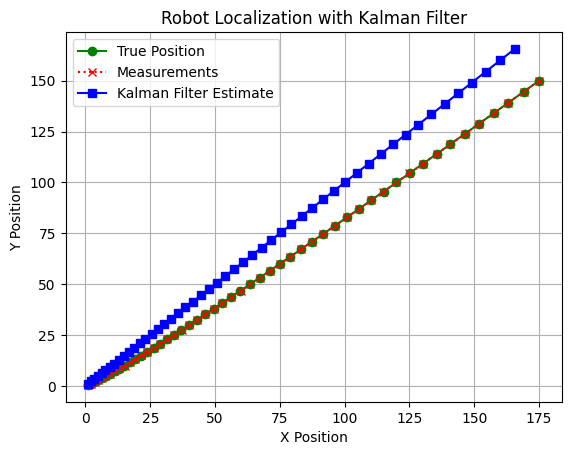

In [4]:
import numpy as np
import matplotlib.pyplot as plt

class KalmanFilter:
    def __init__(self, dt, std_acc, std_meas):
        """
        dt: Time step
        std_acc: Standard deviation of the process noise (acceleration noise)
        std_meas: Standard deviation of the measurement noise
        """
        self.dt = dt

        # Initial state [x, y, vx, vy] (position and velocity)
        self.x = np.matrix([[0.0], [0.0], [1.0], [0.5]])  # Match true velocity

        # State covariance matrix
        self.P = np.eye(4) * 10  # Large initial uncertainty

        # State transition matrix (describing the motion model)
        self.A = np.matrix([[1, 0, dt, 0],
                            [0, 1, 0, dt],
                            [0, 0, 1, 0],
                            [0, 0, 0, 1]])

        # Control input matrix (for acceleration in both directions)
        self.B = np.matrix([[0.5 * dt**2, 0],
                            [0, 0.5 * dt**2],
                            [dt, 0],
                            [0, dt]])

        # Process noise covariance (uncertainty in motion)
        self.Q = np.matrix([[0.25 * dt**4, 0, 0.5 * dt**3, 0],
                            [0, 0.25 * dt**4, 0, 0.5 * dt**3],
                            [0.5 * dt**3, 0, dt**2, 0],
                            [0, 0.5 * dt**3, 0, dt**2]]) * std_acc ** 2

        # Measurement matrix (we measure position [x, y] only)
        self.H = np.matrix([[1, 0, 0, 0],
                            [0, 1, 0, 0]])

        # Measurement noise covariance (measurement uncertainty)
        self.R = np.eye(2) * std_meas ** 2

    def predict(self, u):
        """ Predict the next state based on control input u (acceleration) """
        # Scale acceleration by dt to prevent excessive growth
        # BUG BUG. This is double scaling the acceleration.
        # u_scaled = u * self.dt

        # Apply the state transition and control input
        #B_u_scaled = np.dot(self.B, u_scaled)
        #self.x = np.dot(self.A, self.x) + B_u_scaled.T
        self.x = np.dot(self.A, self.x) + np.dot(self.B, u)
        self.P = np.dot(np.dot(self.A, self.P), self.A.T) + self.Q

    def update(self, z):
        """ Update the state with a new measurement z (position) """
        y = z - np.dot(self.H, self.x)  # Measurement residual
        S = np.dot(np.dot(self.H, self.P), self.H.T) + self.R  # Residual covariance
        K = np.dot(np.dot(self.P, self.H.T), np.linalg.inv(S))  # Kalman gain

        # Update the state estimate with the measurement
        self.x = self.x + np.dot(K, y)

        # Update the covariance matrix
        I = np.eye(self.P.shape[0])  # Identity matrix
        self.P = np.dot(I - np.dot(K, self.H), self.P)

    def get_state(self):
        """ Return the current estimated state """
        return self.x

# Simulating robot localization
if __name__ == "__main__":
    dt = 1  # Time step (1 second)
    std_acc = 0.0001  # Acceleration noise
    std_meas = 0.05  # Measurement noise (sensor noise)

    kf = KalmanFilter(dt, std_acc, std_meas)

    # Simulate robot movement and sensor measurements
    num_steps = 50
    true_positions = []
    measurements = []
    estimates = []

    # Simulated true motion of the robot (assuming constant acceleration)
    true_position = np.array([0.0, 0.0])  # Ensure float type
    true_velocity = np.array([1.0, 0.5])  # Ensure float type
    acceleration = np.array([0.1, 0.1])  # Constant acceleration

    # Initial noisy measurement
    measurement = true_position + np.random.normal(0, std_meas, size=2)

    for t in range(num_steps):
        # True position based on constant acceleration model
        true_position += true_velocity * dt + 0.5 * acceleration * dt**2
        true_velocity += acceleration * dt
        true_positions.append(true_position.copy())

        # Simulate noisy measurements (sensor data)
        measurement = true_position + np.random.normal(0, std_meas, size=2)
        measurements.append(measurement)

        # Kalman filter prediction step
        kf.predict(u=acceleration)

        # Kalman filter update step with the noisy measurement
        kf.update(z=np.matrix(measurement).T)

        # Store estimated position
        estimates.append(kf.get_state()[0:2].A1)  # Extract position from state

    # Convert to numpy arrays for easy plotting
    true_positions = np.array(true_positions)
    measurements = np.array(measurements)
    estimates = np.array(estimates)

    # Plot the true position, noisy measurements, and Kalman Filter estimates
    plt.plot(true_positions[:, 0], true_positions[:, 1], label='True Position', color='g', marker='o')
    plt.plot(measurements[:, 0], measurements[:, 1], label='Measurements', color='r', linestyle='dotted', marker='x')
    plt.plot(estimates[:, 0], estimates[:, 1], label='Kalman Filter Estimate', color='b', marker='s')
    plt.legend()
    plt.xlabel('X Position')
    plt.ylabel('Y Position')
    plt.title('Robot Localization with Kalman Filter')
    plt.grid()
    plt.show()
